# Reglas de Negocio — Churn Prediction

Aplicación del modelo XGBoost a nuevos clientes:
1. Umbral óptimo de decisión
2. Segmentación por riesgo
3. Diseño de acción comercial
4. CLTV (Customer Lifetime Value)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from scipy.optimize import minimize_scalar
from sklearn.metrics import f1_score, roc_curve, precision_recall_curve
from sklearn.model_selection import cross_val_predict
from transformer import BinaryEncoder, FrequencyEncoder, OrdinalExtensionEncoder, OrdinalEquipamientoEncoder, NominalOneHotEncoder, PriceStandard, InstanceDropper, ColumnDropper
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

warnings.filterwarnings('ignore')
%matplotlib inline

## 1. Parámetros de Negocio

> **NOTA:** Aquí están todos los parámetros económicos. Modifica este bloque cuando tengas los valores definitivos.

| Variable | Descripción | Decisión tomada |
|---|---|---|
| `PRECIO_MULTIPLIER` | Precio mantenimiento = C(n) × multiplier | 1.70 (mínimo teórico ≈1.587) |
| `MARGEN_MINIMO` | Margen mínimo del concesionario | 30% |
| `COMISION_MARCA` | % del precio que va a la marca | 7% |
| `ELASTICIDAD_DESCUENTO` | Sensibilidad del churn al descuento (λ) | 0.50 |

**Punto 6 — "Ingreso generado":** se interpreta como el precio P cobrado al cliente por el mantenimiento. El 7% de P va a la marca. Cambia `COMISION_MARCA` y `calcular_precio()` si es otro concepto.

**Punto 7 — "Margen mínimo 30%":** `Margen = (0.93·P − C(n)) / P ≥ 0.30` → `P ≥ C(n) / 0.63`. Cambia `MARGEN_MINIMO` si la base de cálculo es distinta.

In [2]:
# Costes de mantenimiento
ALPHA_AB    = 0.07   # alpha para modelos A y B
ALPHA_RESTO = 0.10   # alpha para el resto de modelos

# Precio cobrado al cliente: P = C(n) * PRECIO_MULTIPLIER
# Minimo para cumplir margen: P >= C(n) / (1 - COMISION_MARCA - MARGEN_MINIMO) ~= C(n) * 1.587
PRECIO_MULTIPLIER = 1.70

# Restricciones de margen
COMISION_MARCA = 0.07   # 7% del precio va a la marca
MARGEN_MINIMO  = 0.30   # margen minimo del concesionario

# Accion comercial
DESCUENTO_SEGUNDO_VEHICULO = 1000  # euros fijo para n >= 5

# Descuento por bajo riesgo: optimizado automaticamente en seccion 6.2
# Lambda: cuanto reduce el churn un descuento del 100% (0=sin efecto, 1=churn=0)
ELASTICIDAD_DESCUENTO = 0.50

# CLTV
TASA_DESCUENTO_CLTV    = 0.08  # tasa anual de descuento
MANTENIMIENTOS_ANUALES = 1     # mantenimientos esperados por cliente por anio

# Segmentacion de riesgo
UMBRAL_BAJO_RIESGO = 0.30
UMBRAL_ALTO_RIESGO = 0.60

print('Parametros cargados OK')
umbral_minimo = 1 / (1 - COMISION_MARCA - MARGEN_MINIMO)
print(f'  Precio minimo = C(n) x {umbral_minimo:.3f}')
print(f'  Precio base   = C(n) x {PRECIO_MULTIPLIER:.2f}')

Parametros cargados OK
  Precio minimo = C(n) x 1.587
  Precio base   = C(n) x 1.70


## 2. Carga del Modelo y Datos

In [3]:
xgb_model = joblib.load('data/warehouse/xgboost.pkl')
pipeline  = joblib.load('data/warehouse/num_pipeline.pkl')

X_train = joblib.load('data/warehouse/X_train_prepared.pkl')
y_train = joblib.load('data/warehouse/y_train.pkl')

nuevos    = pd.read_csv('data/lake/nuevos_clientes.csv')
costes_df = pd.read_csv('data/lake/costes.csv')

print(f'Nuevos clientes: {len(nuevos):,}')
#print(f'Modelos en costes: {costes_df["Modelo"].tolist()}')

Nuevos clientes: 10,000


## 3. Preprocesamiento de Nuevos Clientes

Adaptaciones respecto al training set:
- `Lead_compra_1` → `Fue_Lead` (mismo concepto, nombre distinto)
- `Churn_400` no existe → se añade dummy `'N'` (requerido por BinaryEncoder)
- `RENTA_MEDIA_ESTIMADA = 0` → se rellena con la media de los no-cero del propio CSV
- `DAYS_LAST_SERVICE` no existe → se añade como `NaN` (el pipeline la descarta)

In [4]:
df = nuevos.copy()

# 1. Renombrar columna equivalente
df = df.rename(columns={'Lead_compra_1': 'Fue_Lead'})

# 2. Columnas requeridas por el pipeline que no existen en nuevos clientes
df['Churn_400']         = 'N'
df['DAYS_LAST_SERVICE'] = np.nan

# 3. Parsear fechas
for col in ['Sales_Date', 'FIN_GARANTIA', 'BASE_DATE']:
    df[col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True, format='%d/%m/%Y')

# 4. Rellenar RENTA_MEDIA_ESTIMADA == 0 con la media de los no-cero
df['RENTA_MEDIA_ESTIMADA'] = df['RENTA_MEDIA_ESTIMADA'].astype(float)
media_renta = df.loc[df['RENTA_MEDIA_ESTIMADA'] != 0, 'RENTA_MEDIA_ESTIMADA'].mean()
n_zeros     = (df['RENTA_MEDIA_ESTIMADA'] == 0).sum()
df.loc[df['RENTA_MEDIA_ESTIMADA'] == 0, 'RENTA_MEDIA_ESTIMADA'] = media_renta
print(f'  RENTA_MEDIA_ESTIMADA: {n_zeros} valores 0 rellenados con media = {media_renta:.0f} euros')

# 5. Aplicar pipeline
df_prep = pipeline.fit_transform(df)

# 6. Separar target dummy y conservar info util para reglas de negocio
X_new = df_prep.drop(columns=['Churn_400'], errors='ignore')

info_clientes = df[['Customer_ID', 'Modelo', 'Revisiones', 'PVP', 'RENTA_MEDIA_ESTIMADA']].copy()
info_clientes = info_clientes.loc[X_new.index].reset_index(drop=True)
X_new         = X_new.reset_index(drop=True)

print(f'  Shape tras pipeline: {X_new.shape}')
print(f'  Clientes validos: {len(X_new):,}')

  RENTA_MEDIA_ESTIMADA: 2225 valores 0 rellenados con media = 28392 euros
  Shape tras pipeline: (10000, 35)
  Clientes validos: 10,000


## 4. Umbral de Decisión Óptimo

Se usan los datos de training con cross-validation (sin data leakage) para encontrar el threshold que maximiza el **F1-score**. También se calcula el umbral de Youden (maximiza TPR − FPR) para comparar.

In [5]:
print('Calculando probabilidades CV en training (puede tardar ~1 min)...')
y_proba_cv = cross_val_predict(xgb_model, X_train, y_train, cv=5, method='predict_proba')[:, 1]

# Umbral por maximo F1
precisions, recalls, thresholds_pr = precision_recall_curve(y_train, y_proba_cv)
f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-9)
idx_f1    = np.argmax(f1_scores)
umbral_f1 = thresholds_pr[idx_f1]

# Umbral por Youden
fpr, tpr, thresholds_roc = roc_curve(y_train, y_proba_cv)
idx_youden    = np.argmax(tpr - fpr)
umbral_youden = thresholds_roc[idx_youden]

print(f'\n  Umbral F1 maximo : {umbral_f1:.4f}  (F1 = {f1_scores[idx_f1]:.4f})')
print(f'  Umbral Youden    : {umbral_youden:.4f}  (TPR={tpr[idx_youden]:.3f}, FPR={fpr[idx_youden]:.3f})')

UMBRAL_DECISION = umbral_f1
print(f'\n  Umbral seleccionado: {UMBRAL_DECISION:.4f} (F1 maximo)')

Calculando probabilidades CV en training (puede tardar ~1 min)...

  Umbral F1 maximo : 0.2604  (F1 = 0.5405)
  Umbral Youden    : 0.0920  (TPR=0.925, FPR=0.215)

  Umbral seleccionado: 0.2604 (F1 maximo)


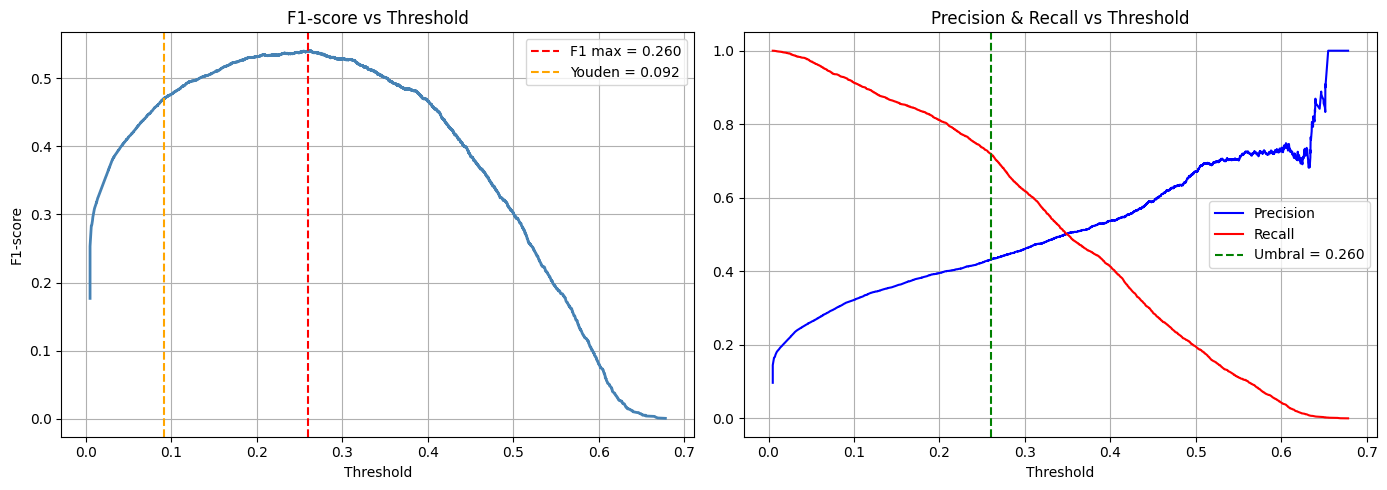

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds_pr, f1_scores, color='steelblue', lw=2)
axes[0].axvline(umbral_f1,     color='red',    ls='--', label=f'F1 max = {umbral_f1:.3f}')
axes[0].axvline(umbral_youden, color='orange', ls='--', label=f'Youden = {umbral_youden:.3f}')
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('F1-score')
axes[0].set_title('F1-score vs Threshold'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(thresholds_pr, precisions[:-1], 'b-', label='Precision')
axes[1].plot(thresholds_pr, recalls[:-1],    'r-', label='Recall')
axes[1].axvline(UMBRAL_DECISION, color='green', ls='--', label=f'Umbral = {UMBRAL_DECISION:.3f}')
axes[1].set_xlabel('Threshold'); axes[1].set_title('Precision & Recall vs Threshold')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout(); plt.show()

## 5. Probabilidades de Churn y Segmentación de Riesgo

In [7]:
p_churn = xgb_model.predict_proba(X_new)[:, 1]
y_pred  = (p_churn >= UMBRAL_DECISION).astype(int)

def segmentar_riesgo(p):
    if p < UMBRAL_BAJO_RIESGO:
        return 'Bajo'
    elif p < UMBRAL_ALTO_RIESGO:
        return 'Medio'
    else:
        return 'Alto'

segmento = [segmentar_riesgo(p) for p in p_churn]

resultados = info_clientes.copy()
resultados['p_churn']    = p_churn.round(4)
resultados['Churn_pred'] = y_pred
resultados['Segmento']   = segmento

print('Distribucion por segmento de riesgo:')
dist = resultados['Segmento'].value_counts()
for seg, n in dist.items():
    print(f'  {seg:6s}: {n:5,}  ({100*n/len(resultados):.1f}%)')
print(f'\nClientes predichos como Churn (umbral={UMBRAL_DECISION:.3f}): {y_pred.sum():,}')

Distribucion por segmento de riesgo:
  Bajo  : 10,000  (100.0%)

Clientes predichos como Churn (umbral=0.260): 0


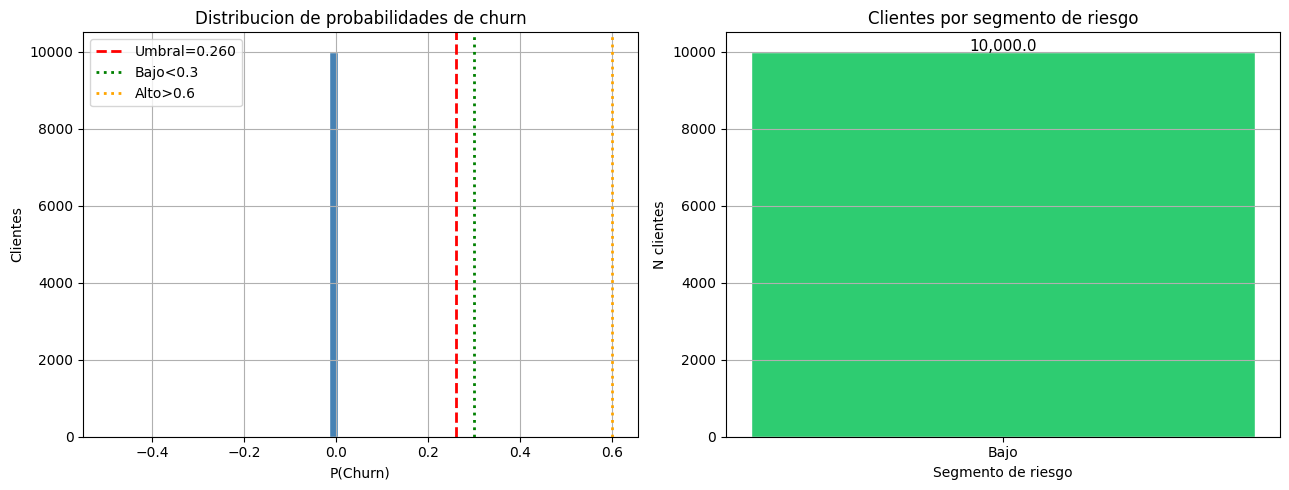

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colores = {'Bajo': '#2ecc71', 'Medio': '#f39c12', 'Alto': '#e74c3c'}

axes[0].hist(p_churn, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(UMBRAL_DECISION,    color='red',    ls='--', lw=2, label=f'Umbral={UMBRAL_DECISION:.3f}')
axes[0].axvline(UMBRAL_BAJO_RIESGO, color='green',  ls=':', lw=2, label=f'Bajo<{UMBRAL_BAJO_RIESGO}')
axes[0].axvline(UMBRAL_ALTO_RIESGO, color='orange', ls=':', lw=2, label=f'Alto>{UMBRAL_ALTO_RIESGO}')
axes[0].set_xlabel('P(Churn)'); axes[0].set_ylabel('Clientes')
axes[0].set_title('Distribucion de probabilidades de churn')
axes[0].legend(); axes[0].grid(True)

valores = resultados['Segmento'].value_counts().reindex(['Bajo', 'Medio', 'Alto'])
axes[1].bar(valores.index, valores.values,
            color=[colores[s] for s in valores.index], edgecolor='white')
axes[1].set_xlabel('Segmento de riesgo'); axes[1].set_ylabel('N clientes')
axes[1].set_title('Clientes por segmento de riesgo')
for i, (seg, val) in enumerate(zip(valores.index, valores.values)):
    axes[1].text(i, val + 20, f'{val:,}', ha='center', fontsize=11)
axes[1].grid(axis='y')
plt.tight_layout(); plt.show()

## 6. Reglas de Negocio

### 6.1 Coste de Mantenimiento C(n)

`C(n) = BASE × (1 + α)^n`

- `BASE` = columna `Mantenimiento_medio` de `costes.csv`
- `α = 7%` para modelos A y B; `α = 10%` para el resto
- `n = 1` para todos los nuevos clientes (primer mantenimiento)

In [9]:
costes = costes_df.set_index('Modelo')

def calcular_cn(modelo, n):
    base  = costes.loc[modelo, 'Mantenimiento_medio']
    alpha = ALPHA_AB if modelo in ('A', 'B') else ALPHA_RESTO
    return base * (1 + alpha) ** n

def calcular_precio(cn):
    # PUNTO 6 & 7: P = C(n) * PRECIO_MULTIPLIER
    # Minimo para margen >= 30%: P >= C(n) / (1 - COMISION_MARCA - MARGEN_MINIMO)
    # Cambia PRECIO_MULTIPLIER en la seccion de parametros si tienes precio de referencia
    return cn * PRECIO_MULTIPLIER

resultados['n_mantenimiento'] = 1
resultados['C_n']            = resultados['Modelo'].apply(lambda m: calcular_cn(m, 1))
resultados['CosteMarketing'] = resultados['C_n'] * 0.01
resultados['Precio_base']    = resultados['C_n'].apply(calcular_precio)

# Verificacion de margen
margen_real = (1 - COMISION_MARCA) - resultados['C_n'] / resultados['Precio_base']
assert (margen_real >= MARGEN_MINIMO).all(), \
    f"ERROR: {(margen_real < MARGEN_MINIMO).sum()} clientes no cumplen margen minimo. Sube PRECIO_MULTIPLIER."

print('Coste y precio calculados OK')
print(resultados.groupby('Modelo')[['C_n', 'CosteMarketing', 'Precio_base']].mean().round(2))

Coste y precio calculados OK
           C_n  CosteMarketing  Precio_base
Modelo                                     
A       267.50            2.68       454.75
B       281.41            2.81       478.40
C       303.60            3.04       516.12
D       319.00            3.19       542.30
E       335.50            3.36       570.35
F       352.00            3.52       598.40
G       369.60            3.70       628.32
H       388.30            3.88       660.11
I       408.10            4.08       693.77
J       429.00            4.29       729.30
K       451.00            4.51       766.70


### 6.2 Descuento Óptimo para Clientes de Bajo Riesgo

Se optimiza `d*` que maximiza el **ingreso esperado neto**:

`E[Margen(d)] = (0.93 · P · (1−d) − C(n)) · (1 − p_churn · (1 − λ·d))`

- `0.93·P` = precio tras comisión de marca (7%)
- `(1 − p_churn·(1−λd))` = probabilidad de retención con descuento `d`
- `λ = ELASTICIDAD_DESCUENTO`

Restricción: `d ≤ d_max` donde el margen del concesionario = 30%

Descuento optimo medio (bajo riesgo): 0.0%
Descuento maximo medio (bajo riesgo): 6.6%


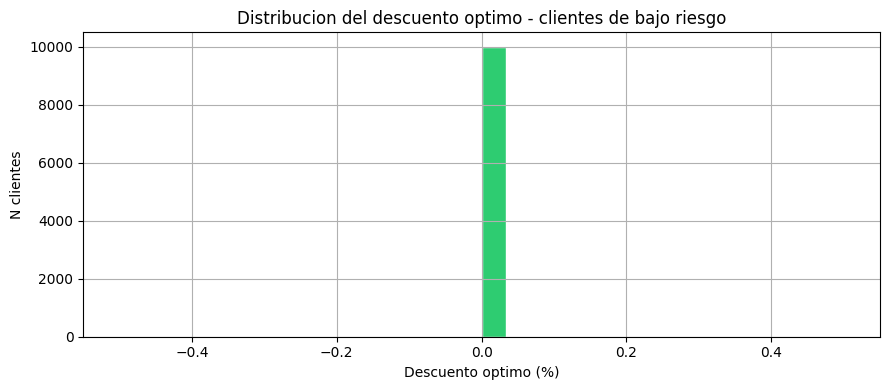

In [10]:
def descuento_optimo(p_churn_c, cn, precio, lam=ELASTICIDAD_DESCUENTO):
    factor_marca       = 1 - COMISION_MARCA
    margen_minimo_neto = 1 - COMISION_MARCA - MARGEN_MINIMO  # 0.63
    d_max = max(0.0, 1 - cn / (margen_minimo_neto * precio))

    def neg_margen(d):
        p_ret        = 1 - p_churn_c * max(0.0, 1 - lam * d)
        margen_bruto = factor_marca * precio * (1 - d) - cn
        return -(margen_bruto * p_ret)

    if d_max <= 0:
        return 0.0, 0.0, round((factor_marca * precio - cn) * (1 - p_churn_c), 2)

    res   = minimize_scalar(neg_margen, bounds=(0, d_max), method='bounded')
    d_opt = round(res.x, 4)
    return d_opt, round(d_max, 4), round(-res.fun, 2)


mask_bajo = resultados['Segmento'] == 'Bajo'

opts = resultados.loc[mask_bajo].apply(
    lambda r: descuento_optimo(r['p_churn'], r['C_n'], r['Precio_base']),
    axis=1, result_type='expand'
).rename(columns={0: 'd_optimo', 1: 'd_max', 2: 'margen_esperado'})

resultados.loc[mask_bajo, 'd_optimo']        = opts['d_optimo'].values
resultados.loc[mask_bajo, 'd_max']           = opts['d_max'].values
resultados.loc[mask_bajo, 'margen_esperado'] = opts['margen_esperado'].values

factor_marca       = 1 - COMISION_MARCA
margen_minimo_neto = 1 - COMISION_MARCA - MARGEN_MINIMO
for idx in resultados.index[~mask_bajo]:
    cn = resultados.at[idx, 'C_n']
    p  = resultados.at[idx, 'Precio_base']
    pc = resultados.at[idx, 'p_churn']
    resultados.at[idx, 'd_optimo']        = 0.0
    resultados.at[idx, 'd_max']           = max(0.0, 1 - cn / (margen_minimo_neto * p))
    resultados.at[idx, 'margen_esperado'] = (factor_marca * p - cn) * (1 - pc)

print(f'Descuento optimo medio (bajo riesgo): {resultados.loc[mask_bajo, "d_optimo"].mean()*100:.1f}%')
print(f'Descuento maximo medio (bajo riesgo): {resultados.loc[mask_bajo, "d_max"].mean()*100:.1f}%')

plt.figure(figsize=(9, 4))
plt.hist(resultados.loc[mask_bajo, 'd_optimo'] * 100, bins=30, color='#2ecc71', edgecolor='white')
plt.xlabel('Descuento optimo (%)'); plt.ylabel('N clientes')
plt.title('Distribucion del descuento optimo - clientes de bajo riesgo')
plt.grid(True); plt.tight_layout(); plt.show()

### 6.3 Oferta Segundo Vehículo (n ≥ 5)

Descuento fijo de 1.000 € aplicable cuando el cliente lleva 5 o más mantenimientos.
Como todos los nuevos clientes tienen `n = 1`, la condición no se activa ahora pero queda preparada para revisiones futuras.

In [11]:
resultados['oferta_2o_vehiculo'] = resultados['n_mantenimiento'] >= 5
print(f'Clientes elegibles para oferta 2 vehiculo (n>=5): {resultados["oferta_2o_vehiculo"].sum()}')
print('(Para nuevos clientes con n=1 este valor es 0. La logica aplica en revisiones futuras.)')

Clientes elegibles para oferta 2 vehiculo (n>=5): 0
(Para nuevos clientes con n=1 este valor es 0. La logica aplica en revisiones futuras.)


## 7. CLTV — Customer Lifetime Value

Fórmula estándar para negocio con retención constante:

`CLTV = Margen_anual × Tasa_retención / (1 + Tasa_descuento − Tasa_retención)`

- `Margen_anual = Margen_mantenimiento × MANTENIMIENTOS_ANUALES`
- `Tasa_retención = 1 − p_churn`
- `Tasa_descuento = TASA_DESCUENTO_CLTV` (8% por defecto)

A mayor CLTV, mayor prioridad para la acción comercial.

CLTV por segmento de riesgo:
            count     mean     std      min      25%      50%      75%  \
Segmento                                                                 
Bajo      10000.0  2267.44  399.59  1821.62  1916.35  2172.33  2779.08   

              max  
Segmento           
Bajo      3071.23  


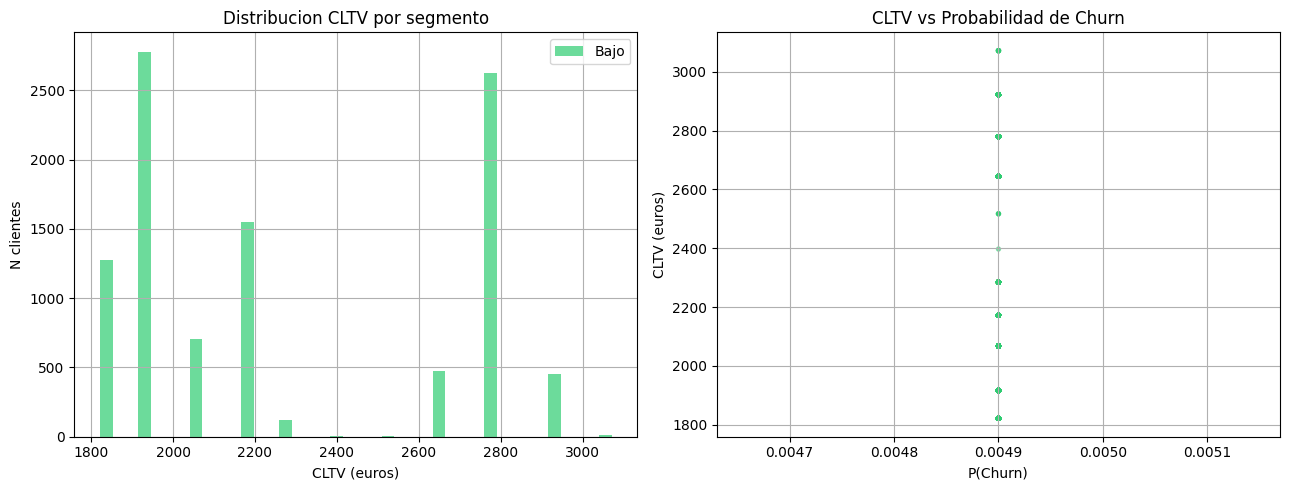

In [12]:
def calcular_cltv(p_churn_c, cn, precio, d_aplicado=0.0):
    precio_ef    = precio * (1 - d_aplicado)
    margen_mant  = (1 - COMISION_MARCA) * precio_ef - cn
    margen_anual = margen_mant * MANTENIMIENTOS_ANUALES
    tasa_ret     = 1 - p_churn_c
    denominador  = 1 + TASA_DESCUENTO_CLTV - tasa_ret
    if denominador <= 0 or margen_anual <= 0:
        return 0.0
    return round(margen_anual * tasa_ret / denominador, 2)

resultados['CLTV'] = resultados.apply(
    lambda r: calcular_cltv(r['p_churn'], r['C_n'], r['Precio_base'], r['d_optimo']),
    axis=1
)

print('CLTV por segmento de riesgo:')
print(resultados.groupby('Segmento')['CLTV'].describe().round(2))

colores = {'Bajo': '#2ecc71', 'Medio': '#f39c12', 'Alto': '#e74c3c'}
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for seg, grp in resultados.groupby('Segmento'):
    axes[0].hist(grp['CLTV'], bins=40, alpha=0.7, label=seg, color=colores[seg])
axes[0].set_xlabel('CLTV (euros)'); axes[0].set_ylabel('N clientes')
axes[0].set_title('Distribucion CLTV por segmento'); axes[0].legend(); axes[0].grid(True)

axes[1].scatter(resultados['p_churn'], resultados['CLTV'],
                c=[colores[s] for s in resultados['Segmento']], alpha=0.3, s=8)
axes[1].set_xlabel('P(Churn)'); axes[1].set_ylabel('CLTV (euros)')
axes[1].set_title('CLTV vs Probabilidad de Churn'); axes[1].grid(True)
plt.tight_layout(); plt.show()

## 8. Resumen de Acciones Comerciales

| Segmento | Acción |
|---|---|
| **Bajo** | Descuento óptimo `d*` en mantenimiento (fidelización) |
| **Medio** | Acción de marketing (`CosteMarketing = 1% C(n)`) |
| **Alto** | Acción de marketing intensiva + seguimiento proactivo |
| **n ≥ 5** | Oferta adicional: 1.000 € descuento segundo vehículo |

In [13]:
def recomendar_accion(row):
    acciones = []
    if row['Segmento'] == 'Bajo':
        acciones.append(f"Descuento fidelizacion {row['d_optimo']*100:.1f}%")
    elif row['Segmento'] == 'Medio':
        acciones.append(f"Marketing (coste {row['CosteMarketing']:.2f} euros)")
    else:
        acciones.append('Marketing intensivo + contacto proactivo')
    if row['oferta_2o_vehiculo']:
        acciones.append('Oferta 2 vehiculo (-1000 euros)')
    return ' | '.join(acciones)

resultados['Accion_recomendada'] = resultados.apply(recomendar_accion, axis=1)
resultados['Precio_final'] = resultados['Precio_base'] * (1 - resultados['d_optimo'])
resultados['Margen_final'] = (
    (1 - COMISION_MARCA) * resultados['Precio_final'] - resultados['C_n']
) / resultados['Precio_final']

resumen = resultados.groupby('Segmento').agg(
    N_clientes         = ('Customer_ID', 'count'),
    p_churn_media      = ('p_churn', 'mean'),
    Descuento_medio    = ('d_optimo', 'mean'),
    Precio_final_medio = ('Precio_final', 'mean'),
    Margen_final_medio = ('Margen_final', 'mean'),
    CLTV_medio         = ('CLTV', 'mean'),
    CLTV_total         = ('CLTV', 'sum'),
).round(3)
resumen['Descuento_%'] = (resumen['Descuento_medio'] * 100).round(1)
resumen['Margen_%']    = (resumen['Margen_final_medio'] * 100).round(1)

print('=' * 70)
print('RESUMEN DE ACCIONES COMERCIALES')
print('=' * 70)
display(resumen[['N_clientes', 'p_churn_media', 'Descuento_%',
                  'Precio_final_medio', 'Margen_%', 'CLTV_medio', 'CLTV_total']])
print(f'\nCLTV total cartera: {resultados["CLTV"].sum():,.0f} euros')

RESUMEN DE ACCIONES COMERCIALES


,N_clientes,p_churn_media,Descuento_%,Precio_final_medio,Margen_%,CLTV_medio,CLTV_total
Segmento,,,,,,,
Bajo,10000,0.005,0.0,566.044,34.2,2267.442,22674415.93



CLTV total cartera: 22,674,416 euros


In [14]:
cols = ['Customer_ID', 'Modelo', 'Segmento', 'p_churn',
        'd_optimo', 'Precio_final', 'Margen_final', 'CLTV', 'Accion_recomendada']
print('Top 20 clientes por CLTV (mayor prioridad de accion):')
display(
    resultados.sort_values('CLTV', ascending=False)[cols].head(20)
    .style
    .background_gradient(subset=['CLTV'], cmap='Greens')
    .background_gradient(subset=['p_churn'], cmap='Reds')
    .format({
        'p_churn':      '{:.3f}',
        'd_optimo':     '{:.1%}',
        'Precio_final': '{:.2f} euros',
        'Margen_final': '{:.1%}',
        'CLTV':         '{:,.0f} euros'
    })
)

Top 20 clientes por CLTV (mayor prioridad de accion):


,Customer_ID,Modelo,Segmento,p_churn,d_optimo,Precio_final,Margen_final,CLTV,Accion_recomendada
6056,107086,K,Bajo,0.005,0.0%,766.70 euros,34.2%,"3,071 euros",Descuento fidelizacion 0.0%
5434,101941,K,Bajo,0.005,0.0%,766.70 euros,34.2%,"3,071 euros",Descuento fidelizacion 0.0%
2341,106713,K,Bajo,0.005,0.0%,766.70 euros,34.2%,"3,071 euros",Descuento fidelizacion 0.0%
6037,107690,K,Bajo,0.005,0.0%,766.70 euros,34.2%,"3,071 euros",Descuento fidelizacion 0.0%
4700,100521,K,Bajo,0.005,0.0%,766.70 euros,34.2%,"3,071 euros",Descuento fidelizacion 0.0%
5639,103928,K,Bajo,0.005,0.0%,766.70 euros,34.2%,"3,071 euros",Descuento fidelizacion 0.0%
7886,107453,K,Bajo,0.005,0.0%,766.70 euros,34.2%,"3,071 euros",Descuento fidelizacion 0.0%
3335,105337,K,Bajo,0.005,0.0%,766.70 euros,34.2%,"3,071 euros",Descuento fidelizacion 0.0%
4768,98205,K,Bajo,0.005,0.0%,766.70 euros,34.2%,"3,071 euros",Descuento fidelizacion 0.0%
5901,40995,K,Bajo,0.005,0.0%,766.70 euros,34.2%,"3,071 euros",Descuento fidelizacion 0.0%


In [15]:
output_cols = [
    'Customer_ID', 'Modelo', 'Revisiones', 'PVP',
    'p_churn', 'Churn_pred', 'Segmento',
    'n_mantenimiento', 'C_n', 'CosteMarketing',
    'Precio_base', 'd_optimo', 'd_max', 'Precio_final', 'Margen_final',
    'oferta_2o_vehiculo', 'CLTV', 'Accion_recomendada'
]
resultados[output_cols].to_csv('data/warehouse/clientes_scored.csv', index=False)
print('Resultados exportados: data/warehouse/clientes_scored.csv OK')

Resultados exportados: data/warehouse/clientes_scored.csv OK
